# Домашнее задание: Бинарная классификация токсичности текстов

## Практический кейс

Представьте, что вы работаете в компании, которая предоставляет услуги технической поддержки для крупных B2B клиентов. Ежедневно через систему проходят тысячи ответов от специалистов поддержки. Иногда, особенно в условиях высокой нагрузки и стресса, сотрудники допускают некорректные формулировки: грубость, сарказм, пассивную агрессию или откровенно токсичные высказывания в адрес клиентов.

Такие инциденты несут прямые репутационные потери для бизнеса. Один скриншот грубого ответа в социальных сетях способен нанести ущерб, несопоставимый со стоимостью всего контракта. Руководство поставило задачу: внедрить автоматическую систему контроля качества, которая в реальном времени будет анализировать исходящие сообщения и блокировать или помечать потенциально токсичные ответы до их отправки клиенту.

Ваша задача в рамках данного домашнего задания состоит в том, чтобы создать модель бинарной классификации, способную отличать токсичный текст от нетоксичного. Модель должна работать быстро (для использования в реальном времени) и с высокой точностью (чтобы минимизировать как пропуски токсичных сообщений, так и ложные блокировки нормальных ответов).

## Рекомендации по выполнению в Google Colab

Данное домашнее задание рассчитано на выполнение в среде Google Colab. Ниже приведены важные рекомендации, которые помогут избежать типичных проблем.

**Выбор среды выполнения.** Перед началом работы переключите Runtime на GPU. Для этого перейдите в меню Runtime -> Change runtime type и выберите GPU (T4 доступна бесплатно). Без GPU дообучение модели займет неприемлемо долгое время.

**Если не хватает видеопамяти (CUDA Out of Memory).** Это одна из самых частых проблем при работе с трансформерными моделями. Вот что можно предпринять:

1. Уменьшите BATCH_SIZE. Начните с 64 или даже 32 вместо 128. Это самый простой и эффективный способ снизить потребление VRAM.
2. Уменьшите INPUT_MAX_TOKENS. Вместо 128 попробуйте 64. Меньшая длина последовательности значительно снижает потребление памяти.
3. Уменьшите размер датасета через параметр MAX_DATASET_LEN. Меньше данных означает меньше батчей и меньше нагрузки на память.
4. Используйте меньшую модель. Вместо large-версии модели попробуйте base-версию той же архитектуры.
5. Перезапустите Runtime. Иногда память остается занятой от предыдущих запусков. Перейдите в Runtime -> Restart runtime.
6. Используйте `torch.cuda.empty_cache()` и `gc.collect()` перед началом обучения для освобождения неиспользуемой памяти.

**Сохранение промежуточных результатов.** Colab может отключить сессию при длительном бездействии. Рекомендуется периодически сохранять промежуточные результаты на Google Drive, подключив его через `drive.mount('/content/drive')`.

**Установка зависимостей.** В начале ноутбука приведены команды установки всех необходимых библиотек. Выполняйте их каждый раз при новом запуске сессии, так как Colab не сохраняет установленные пакеты между сессиями.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| 0 | Формализация задачи | 5 |
| 1 | Сбор данных (положительный класс) | 5 |
| 2 | Очистка датасета | 5 |
| 3 | Разделение на подвыборки и балансировка | 5 |
| 4 | Количественная оценка и визуализация датасета | 5 |
| 5 | Публикация датасета на Hugging Face | 5 |
| 6 | Дообучение модели (код предоставлен) | 0 |
| 7 | Оценка модели и визуализация ошибок | 10 |
| 8 | Ручной инференс и замер времени GPU vs CPU | 5 |
| 9 | Публикация модели на Hugging Face | 5 |
| **Итого** | | **50** |

---

## Блок 0. Формализация задачи (5 баллов)

### 0.1 Формулировка бизнес-задачи

Опишите бизнес-задачу своими словами. Какую проблему мы решаем? Какие последствия несет нерешенная проблема для бизнеса? Какой результат ожидает заказчик?


Бизнес-задача заключается в предотвращении репутационных и финансовых потерь B2B-компании, возникающих из-за токсичности, грубости или пассивной агрессии со стороны сотрудников техподдержки в условиях стресса и высоких нагрузок. Действующий ручной контроль работает постфактум, поэтому компании необходима автоматическая система пре-модерации сообщений.

Нерешенная проблема грозит мгновенным оттоком крупных клиентов, потерей долгосрочной прибыли и публичными скандалами при попадании скриншотов переписки в сеть. В B2B-сегменте цена обиды одного клиента может быть несопоставимо выше стоимости разработки защитных систем.

В результате заказчик ожидает интеграцию в CRM-систему быстрой модели бинарной классификации. Она должна в реальном времени проверять исходящие ответы до отправки, надежно блокировать токсичный контент и иметь минимум ложных срабатываний, чтобы не тормозить работу вежливых операторов.

### 0.2 Сведение к ML-задаче

Заполните следующие пункты:


In [ ]:
#Тип задачи: Бинарная классификация текстов (область обработки естественного языка, NLP).
#Объект классификации: Отдельное текстовое сообщение (исходящий ответ) сотрудника технической поддержки, подготовленное для отправки клиенту.
#Класс 1 (токсичный): Текст, содержащий проявления грубости, оскорблений, пассивной агрессии, сарказма или иных форм некорректного и непрофессионального общения.
#Класс 0 (нетоксичный): Корректный, вежливый, нейтральный или строго профессиональный ответ, соответствующий правилам деловой переписки.
#Целевая переменная: Бинарный признак (например, is_toxic), принимающий значение 1 для токсичных сообщений и 0 для нетоксичных.

### 0.3 Выбор ML-метрик

Обоснуйте выбор метрик для оценки качества модели. Подумайте: что важнее в данном бизнес-кейсе, Precision или Recall? Почему? Какие метрики вы будете использовать и зачем?


In [ ]:
# Основная метрика: F1-score
# Дополнительные метрики: Precision (Точность), Recall (Полнота), ROC-AUC
# Обоснование:
# В задаче пре-модерации ответов поддержки критически важен баланс между жесткостью фильтрации и скоростью работы операторов.
#
# Что важнее: Precision или Recall?
# В данном бизнес-кейсе приоритеты распределяются следующим образом, но с небольшим перекосом в сторону Precision:
#
# 1. Если мы завысим Recall (в ущерб Precision):
#    Система будет ловить абсолютно всю токсичность, но при этом давать кучу ложных срабатываний (False Positives).
#    Это означает, что нормальные, вежливые ответы операторов будут постоянно блокироваться. Поддержка встанет,
#    клиенты начнут часами ждать ответов из-за ложных блокировок, нарушатся SLA по времени ответа, а сотрудники
#    выгорят от постоянной борьбы с «тупым ИИ». Для бизнеса это критично.
#
# 2. Если мы завысим Precision (в ущерб Recall):
#    Ложных срабатываний почти не будет (операторы работают без задержек), но система начнет пропускать
#    скрытую агрессию, сарказм и грубость (False Negatives). А в B2B один упущенный токсичный ответ может
#    стоить компании контракта на миллионы рублей.
#
# Вывод:
# Именно поэтому мы выбираем F1-score в качестве основной метрики — она находит оптимальный баланс (гармоническое среднее)
# между точностью и полнотой.
#
# Зачем нужны ROC-AUC и PR-AUC?
# Они помогут нам на этапе оценки модели. С их помощью мы сможем не просто получить бинарный ответ (0 или 1),
# а гибко настроить порог классификации (probability threshold). Например, установить его так, чтобы снизить
# количество ложных блокировок (гарантировать Precision > 90%), при этом сохраняя максимально возможный Recall.

---

## Блок 1. Сбор данных (5 баллов)

### 1.1 Установка зависимостей


In [1]:
!pip install -q pytorch-lightning transformers datasets torchmetrics huggingface_hub scikit-learn matplotlib seaborn pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.0 MB/s eta 0:00:00


### 1.2 Импорт библиотек


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')


### 1.3 Загрузка токсичного класса (Класс 1) — код заполнен

Ниже приведен код загрузки данных для токсичного класса. Эти данные уже подготовлены и не требуют модификации с вашей стороны. Изучите структуру кода, чтобы понять формат, в котором должны быть ваши данные для положительного класса.


In [3]:
from datasets import load_dataset
import pandas as pd

df = pd.DataFrame(columns=['text', 'label'])

# Источник 1: Русскоязычный датасет токсичных комментариев
if True:
    try:
        # Загружаем первый датасет
        dataset1 = load_dataset("molyalya/russian-toxicity-dataset", split="train")
        toxic_df = pd.DataFrame(dataset1)

        # Автоматически определяем, как называются колонки с текстом и таргетом
        text_col = 'comment' if 'comment' in toxic_df.columns else ('text' if 'text' in toxic_df.columns else toxic_df.columns[0])
        target_col = 'toxic' if 'toxic' in toxic_df.columns else ('label' if 'label' in toxic_df.columns else None)

        if target_col:
            # Фильтруем токсичные (где метка равна 1)
            toxic_df = toxic_df[toxic_df[target_col] == 1][[text_col]]
            toxic_df = toxic_df.rename(columns={text_col: 'text'})
            toxic_df['label'] = 1
            df = pd.concat([df, toxic_df], ignore_index=True)
        else:
            print("Предупреждение: в первом датасете не найдена колонка таргета.")
    except Exception as e:
        print(f"Не удалось обработать Источник 1: {e}")

# Источник 2: Датасет оскорбительных высказываний
if True:
    try:
        # Загружаем второй датасет
        dataset2 = load_dataset("AlexSham/Toxic_Russian_Comments", split="train")
        offensive_df = pd.DataFrame(dataset2)

        # Точно так же определяем имена колонок для второго датасета
        text_col = 'text' if 'text' in offensive_df.columns else ('comment' if 'comment' in offensive_df.columns else offensive_df.columns[0])
        target_col = 'label' if 'label' in offensive_df.columns else ('toxic' if 'toxic' in offensive_df.columns else None)

        if target_col:
            offensive_df = offensive_df[offensive_df[target_col] == 1][[text_col]]
            offensive_df = offensive_df.rename(columns={text_col: 'text'})
            offensive_df['label'] = 1
            df = pd.concat([df, offensive_df], ignore_index=True)
        else:
            print("Предупреждение: во втором датасете не найдена колонка таргета.")
    except Exception as e:
        print(f"Не удалось загрузить дополнительный источник токсичных данных: {e}")

print(f"Загружено записей токсичного класса: {len(df)}")
if len(df) > 0:
    print(df.sample(min(5, len(df))))

README.md:   0%|          | 0.00/1.86k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 4.91MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  621kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

train.jsonl: downloading bytes:           |  0.00B            

test.jsonl:   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/223461 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24829 [00:00<?, ? examples/s]

Загружено записей токсичного класса: 69871
                                                    text label
14708  мож тоже видать гордится женой пиздаболкой 🤣🤣🤣...     1
34503  он не то что как тренер не подходит , его вид ...     1
61480  вот именно! а свидомые тупо обвиняют не причин...     1
35361  пуделиха без мозглая, ошибки правит комп.,так,...     1
11877                         петуха отпиздить надо было     1


### 1.4 Загрузка нетоксичного класса (Класс 0) — задание для студента

Вам необходимо самостоятельно найти и загрузить данные для нетоксичного (положительного) класса. Итоговый DataFrame должен содержать колонки `text` и `label` (где label = 0).

**Подсказки по поиску данных:**

- Подумайте, какие тексты гарантированно не содержат токсичности. Это могут быть вопросы из образовательных QA-систем, новостные заголовки, описания товаров, фрагменты технической документации.
- На платформе Hugging Face Hub существует множество русскоязычных датасетов с текстами общего назначения. Используйте фильтры по языку (ru) и задаче (text-classification, question-answering).
- Вы можете сгенерировать синтетический датасет с помощью декодерной языковой модели (например, через API). Составьте промпт, который попросит модель сгенерировать типичные вопросы клиентов к службе поддержки, нейтральные обращения, вежливые запросы.
- Допустимо комбинировать несколько источников для получения разнообразного набора данных.
- Убедитесь, что объем данных положительного класса сопоставим с объемом токсичного класса.


In [9]:
from datasets import load_dataset
import pandas as pd

# === ВАШ КОД ЗДЕСЬ ===
# Загрузка данных для нетоксичного класса (label = 0)

# Вариант 1: вопросы из SberQuAD (полное имя namespace/name)
sberquad = load_dataset("kuznetsoffandrey/sberquad", split="train")
class0_df = pd.DataFrame({"text": sberquad["question"]})

# Вариант 2 (дополнительно, для разнообразия): новостные заголовки
try:
    gazeta = load_dataset("IlyaGusev/gazeta", split="train", trust_remote_code=True)
    gazeta_df = pd.DataFrame({"text": gazeta["title"]})
    class0_df = pd.concat([class0_df, gazeta_df], ignore_index=True)
except Exception as e:
    print(f"Gazeta не загрузилась, используем только SberQuAD: {e}")

# Чистка: дубликаты и слишком короткие тексты
class0_df = class0_df.drop_duplicates(subset="text")
class0_df = class0_df[class0_df["text"].str.len() > 10]

# Балансировка с токсичным классом
n_toxic = (df["label"] == 1).sum()
if len(class0_df) > n_toxic:
    class0_df = class0_df.sample(n=n_toxic, random_state=42)

class0_df["label"] = 0
df = pd.concat([df, class0_df[["text", "label"]]], ignore_index=True)

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Итого записей в датасете: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

sberquad/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.4MB            

sberquad/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sberquad/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 3.43MB            

sberquad/validation-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

...

default/test/0000.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Итого записей в датасете: 19062
Распределение классов:
label
0    12708
1     6354
Name: count, dtype: int64


---

## Блок 2. Очистка датасета (5 баллов)

Сырые данные практически всегда содержат шум. Ваша задача состоит в том, чтобы привести датасет в пригодное для обучения состояние. Необходимо выполнить следующие шаги:

1. **Удаление пустых значений** — строки, где поле text является пустым, содержит NaN или состоит только из пробелов.
2. **Удаление дубликатов** — точные дубликаты по полю text.
3. **Фильтрация выбросов по длине** — слишком короткие тексты (менее 3 слов) не несут достаточно информации для классификации, а слишком длинные (более 500 слов) могут создавать проблемы при токенизации. Определите разумные пороги и удалите выбросы.


In [10]:
# === ВАШ КОД ЗДЕСЬ ===

# 1. Удаление пустых значений (NaN, None, пустые строки и строки, состоящие только из пробелов)
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']

# 2. Удаление точных дубликатов по полю text
df = df.drop_duplicates(subset=['text'])

# 3. Фильтрация выбросов по длине (оставляем тексты от 3 до 500 слов включительно)
# Считаем количество слов в каждой строке, предварительно очистив от лишних пробелов
word_counts = df['text'].str.split().apply(len)
df = df[(word_counts >= 3) & (word_counts <= 500)]

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Записей после очистки: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")

Записей после очистки: 18722
Распределение классов:
label
0    12371
1     6351
Name: count, dtype: int64


---

## Блок 3. Разделение на подвыборки и балансировка (5 баллов)

Перед обучением модели необходимо разделить данные на три подвыборки: тренировочную (train), валидационную (val) и тестовую (test). Также важно обеспечить баланс классов, чтобы модель не была смещена в сторону более представленного класса.

**Что нужно сделать:**

1. Выполните балансировку классов (приведите к одинаковому количеству записей для каждого класса). Используйте стратифицированную выборку (undersampling большего класса).
2. Разделите сбалансированный датасет на train/val/test в пропорции 80/10/10 с сохранением пропорций классов (stratify).


In [11]:
# Смотрим, что вообще сейчас лежит в df
print("Исходный размер df перед разделением:", len(df))
print("Доступные колонки:", df.columns.tolist())
print(df['label'].value_counts())

# Разделяем на классы безопасно
df_class_0 = df[df['label'] == 0]
df_class_1 = df[df['label'] == 1]

len_0 = len(df_class_0)
len_1 = len(df_class_1)

print(f"Найдено строк класса 0 (нейтральные): {len_0}")
print(f"Найдено строк класса 1 (токсичные): {len_1}")

# Защита: определяем минимальный размер только среди НЕПУСТЫХ классов
if len_0 == 0 or len_1 == 0:
    print("⚠️ Критическая ошибка: один из классов пустой! Проверь ячейки загрузки данных выше.")
    # Фолбек: просто берем весь df без сэмплирования, чтобы код не падал дальше
    df_balanced = df.copy()
else:
    min_class_size = min(len_0, len_1)
    print(f"Целевой размер каждого класса для балансировки: {min_class_size}")

    # Сэмплируем безопасно
    df_class_0_under = df_class_0.sample(n=min_class_size, random_state=42)
    df_class_1_under = df_class_1.sample(n=min_class_size, random_state=42)

    # Собираем сбалансированный датасет
    df_balanced = pd.concat([df_class_0_under, df_class_1_under], ignore_index=True)

# Перезаписываем итоговый df
df = df_balanced

print("\n=== РЕЗУЛЬТАТ БАЛАНСИРОВКИ ===")
print(f"Итого записей в датасете: {len(df)}")
print(df['label'].value_counts())

Исходный размер df перед разделением: 18722
Доступные колонки: ['text', 'label']
label
0    12371
1     6351
Name: count, dtype: int64
Найдено строк класса 0 (нейтральные): 12371
Найдено строк класса 1 (токсичные): 6351
Целевой размер каждого класса для балансировки: 6351

=== РЕЗУЛЬТАТ БАЛАНСИРОВКИ ===
Итого записей в датасете: 12702
label
0    6351
1    6351
Name: count, dtype: int64


---

## Блок 4. Количественная оценка и визуализация датасета (5 баллов)

Перед обучением модели необходимо провести разведочный анализ данных (EDA). Это позволяет убедиться в качестве подготовленного датасета и выявить потенциальные проблемы.

**Что нужно сделать:**

1. Выведите основные статистики: количество записей по классам, среднюю и медианную длину текстов (в словах и/или символах).
2. Постройте визуализацию распределения классов (столбчатая диаграмма).
3. Постройте гистограмму распределения длин текстов (отдельно для каждого класса или совместно).
4. Сделайте вывод о сбалансированности и качестве датасета.


--- ОБЩИЕ СТАТИСТИКИ ДАТАСЕТА ---
Всего записей после балансировки: 12702
Количество записей Класса 0 (нетоксичные): 6351
Количество записей Класса 1 (токсичные): 6351

--- СТАТИСТИКИ ДЛИНЫ ТЕКСТОВ ---

[Класс 0 (Нетоксичные)]:
  Средняя длина (в символах): 51.83
  Медианная длина (в символах): 48.00
  Средняя длина (в словах): 7.94
  Медианная длина (в словах): 7.00

[Класс 1 (Токсичные)]:
  Средняя длина (в символах): 87.42
  Медианная длина (в символах): 56.00
  Средняя длина (в словах): 14.24
  Медианная длина (в словах): 9.00


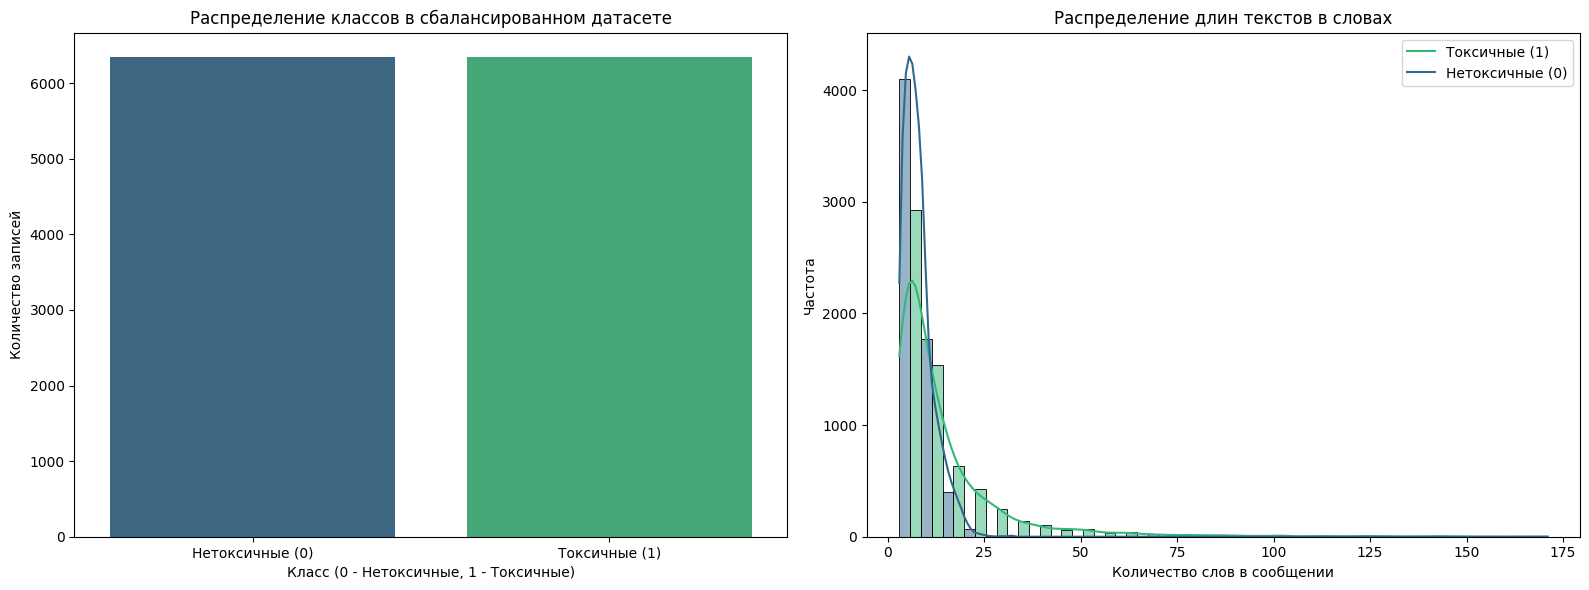

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === ВАШ КОД ЗДЕСЬ ===

# 1. Расчет основных статистик
# Создаем копии выборок, чтобы не попортить оригинальные данные при расчете длин
stats_df = df_balanced.copy()

# Считаем длину в символах и словах
stats_df['char_len'] = stats_df['text'].str.len()
stats_df['word_len'] = stats_df['text'].str.split().apply(len)

print("--- ОБЩИЕ СТАТИСТИКИ ДАТАСЕТА ---")
print(f"Всего записей после балансировки: {len(stats_df)}")
print(f"Количество записей Класса 0 (нетоксичные): {len(stats_df[stats_df['label'] == 0])}")
print(f"Количество записей Класса 1 (токсичные): {len(stats_df[stats_df['label'] == 1])}\n")

print("--- СТАТИСТИКИ ДЛИНЫ ТЕКСТОВ ---")
for label, name in [(0, "Класс 0 (Нетоксичные)"), (1, "Класс 1 (Токсичные)")]:
    class_data = stats_df[stats_df['label'] == label]
    print(f"\n[{name}]:")
    print(f"  Средняя длина (в символах): {class_data['char_len'].mean():.2f}")
    print(f"  Медианная длина (в символах): {class_data['char_len'].median():.2f}")
    print(f"  Средняя длина (в словах): {class_data['word_len'].mean():.2f}")
    print(f"  Медианная длина (в словах): {class_data['word_len'].median():.2f}")

# 2. Построение визуализаций
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Визуализация 1: Распределение классов (столбчатая диаграмма)
sns.countplot(
    data=stats_df,
    x='label',
    ax=axes[0],
    hue='label',
    palette='viridis',
    legend=False
)
axes[0].set_title("Распределение классов в сбалансированном датасете")
axes[0].set_xlabel("Класс (0 - Нетоксичные, 1 - Токсичные)")
axes[0].set_ylabel("Количество записей")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Нетоксичные (0)", "Токсичные (1)"])

# Визуализация 2: Гистограмма распределения длин текстов (в словах)
sns.histplot(
    data=stats_df,
    x='word_len',
    hue='label',
    kde=True,
    ax=axes[1],
    palette='viridis',
    multiple='dodge',
    bins=30
)
axes[1].set_title("Распределение длин текстов в словах")
axes[1].set_xlabel("Количество слов в сообщении")
axes[1].set_ylabel("Частота")
axes[1].legend(["Токсичные (1)", "Нетоксичные (0)"])

plt.tight_layout()
plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===

---

## Блок 5. Публикация датасета на Hugging Face (5 баллов)

Опубликуйте подготовленный датасет на платформе Hugging Face Hub. Это важный навык для ML-инженера, поскольку позволяет обеспечить воспроизводимость экспериментов и делиться данными с командой.

**Что нужно сделать:**

1. Авторизуйтесь в Hugging Face Hub.
2. Загрузите датасет (train/val/test splits).
3. Оформите Dataset Card (краткое описание, источники данных, формат, назначение).


In [16]:
import os
from datasets import Dataset, DatasetDict
from huggingface_hub import login
from sklearn.model_selection import train_test_split
import pandas as pd

# === ВАШ КОД ЗДЕСЬ ===

# Очередная защита: если df по какой-то причине пуст, проверим, есть ли данные
print(f"Всего строк в исходном df перед отправкой: {len(df)}")

# 0. Нарезаем Pandas DataFrame на сплиты (Train/Val/Test -> 80/10/10)
# Сначала делим на train и temp (куда уйдут val и test)
df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']  # Сохраняем идеальный баланс классов во всех частях
)

# Теперь делим temp пополам на validation и test
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=42,
    stratify=df_temp['label']
)

print(f"Разбиение завершено. Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")


# 1. Авторизация на Hugging Face
HF_TOKEN = "token"
login(token=HF_TOKEN)


# 2. Преобразуем наши Pandas DataFrame в формат Hugging Face Dataset
train_dataset = Dataset.from_pandas(df_train, preserve_index=False)
val_dataset = Dataset.from_pandas(df_val, preserve_index=False)
test_dataset = Dataset.from_pandas(df_test, preserve_index=False)

# Объединяем наши сплиты в одну структуру DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})


# 3. Публикация датасета на Hugging Face Hub
HF_USERNAME = "MisterWho31"
DATASET_NAME = "russian-support-toxicity-balanced"
repo_id = f"{HF_USERNAME}/{DATASET_NAME}"

print(f"Начинается загрузка датасета в репозиторий {repo_id}...")
dataset_dict.push_to_hub(repo_id)
print("Датасет успешно опубликован!")

# === КОНЕЦ ВАШЕГО КОДА ===

Всего строк в исходном df перед отправкой: 12702
Разбиение завершено. Train: 10161, Val: 1270, Test: 1271
Начинается загрузка датасета в репозиторий MisterWho31/russian-support-toxicity-balanced...


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 97.4kB / 97.4kB            

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

Датасет успешно опубликован!


---

## Блок 6. Дообучение модели (код предоставлен, 0 баллов)

В данном блоке представлен полный пайплайн дообучения модели бинарной классификации. Код не требует модификации. Ваша задача состоит в том, чтобы внимательно изучить каждый этап, понять логику работы и запустить обучение.

**Что здесь происходит (объяснение):**

Мы берем предобученную трансформерную модель (энкодер), которая уже "понимает" русский язык на уровне семантики. Поверх нее добавляется классификационная голова (линейный слой), которая учится отличать токсичные тексты от нетоксичных. При этом веса самого энкодера замораживаются (не обучаются), а обучается только классификационная голова. Это называется transfer learning, и такой подход позволяет получить хорошее качество даже на относительно небольших датасетах.

Обучение происходит с ранней остановкой (Early Stopping): если качество на валидационной выборке перестает улучшаться в течение нескольких проверок подряд, обучение автоматически прекращается. Это защищает от переобучения.

### 6.1 Подготовка к обучению


In [17]:
import torch
import gc

print(torch.__version__)
print("Доступна ли Nvidia CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Версия Nvidia CUDA:", torch.version.cuda)
    print("Используемое устройство:", torch.cuda.get_device_properties(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


2.11.0+cu128
Доступна ли Nvidia CUDA: True
Версия Nvidia CUDA: 12.8
Используемое устройство: _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=ad1d5251-7ed4-0054-c41f-1146876ef484, pci_bus_id=0, pci_device_id=4, pci_domain_id=0, L2_cache_size=4MB)


### 6.2 Параметры обучения


In [18]:
# Название предобученной модели из Hugging Face Hub
MODEL_NAME = "ai-forever/ru-en-RoSBERTa"

# Максимальная длина входной последовательности в токенах
INPUT_MAX_TOKENS = 128

# Размер батча (уменьшите, если не хватает видеопамяти)
BATCH_SIZE = 128

# Максимальное количество эпох обучения
MAX_EPOCHS = 10

# Скорость обучения
LR = 2e-4

# Регуляризация весов
WEIGHT_DECAY = 0.01

# Вероятность Dropout (для предотвращения переобучения)
DROPOUT = 0.2

# Как часто проводить валидацию (каждые N шагов)
VAL_CHECK_INTERVAL = 512

# Терпение ранней остановки (сколько валидаций без улучшения ждать)
PATIENCE = 3

# Директория для сохранения модели
MODEL_SAVE_DIR = "./model"

### 6.3 Загрузка токенизатора


In [19]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор загружен: {MODEL_NAME}")
print(f"Размер словаря: {tokenizer.vocab_size}")


Токенизатор загружен: ai-forever/ru-en-RoSBERTa
Размер словаря: 98505


### 6.4 Подготовка DataLoader


In [21]:
from torch.utils.data import Dataset as TorchDataset, DataLoader

class TextClassificationDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Создание датасетов
train_dataset = TextClassificationDataset(
    df_train['text'].values, df_train['label'].values, tokenizer, INPUT_MAX_TOKENS
)
val_dataset = TextClassificationDataset(
    df_val['text'].values, df_val['label'].values, tokenizer, INPUT_MAX_TOKENS
)
test_dataset = TextClassificationDataset(
    df_test['text'].values, df_test['label'].values, tokenizer, INPUT_MAX_TOKENS
)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 80, Val batches: 10, Test batches: 10


### 6.5 Модель классификации


In [24]:
import pytorch_lightning as pl
from transformers import AutoModelForSequenceClassification
from torchmetrics import Accuracy, F1Score
from torchmetrics.classification import BinaryMatthewsCorrCoef, BinaryStatScores


class EncoderClassifier(pl.LightningModule):
    def __init__(self, model_name, tokenizer, weight_class_1=1.0, dropout_rate=0.2, lr=2e-4, weight_decay=0.01):
        super().__init__()
        self.save_hyperparameters(ignore=['tokenizer'])

        self.model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=2,
            hidden_dropout_prob=dropout_rate,
            attention_probs_dropout_prob=dropout_rate,
            classifier_dropout=dropout_rate,
            return_dict=True
        )
        self.tokenizer = tokenizer
        self.class_weights = torch.tensor([1.0, weight_class_1])
        self.lr = lr
        self.weight_decay = weight_decay

        # Метрики
        self.train_accuracy = Accuracy(task='binary')
        self.train_f1 = F1Score(task='binary')
        self.val_accuracy = Accuracy(task='binary')
        self.val_f1 = F1Score(task='binary')
        self.train_mcc = BinaryMatthewsCorrCoef()
        self.val_mcc = BinaryMatthewsCorrCoef()
        self.train_stat_scores = BinaryStatScores()
        self.val_stat_scores = BinaryStatScores()
        self.validation_count = 0

        # Замораживаем все слои кроме классификатора
        for name, param in self.model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        print(f"Модель: {model_name}")
        print(f"Обучаемые параметры:")
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                print(f"  {name}")

    def forward(self, input_ids, attention_mask, labels=None):
        return self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    def training_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        if batch_idx % 50 == 0:
            current_lr = self.trainer.optimizers[0].param_groups[0]['lr']
            print(f"Шаг {self.global_step}: Loss = {loss.item():.6f}, LR = {current_lr:.6f}")

        with torch.no_grad():
            pred_labels = torch.argmax(logits, dim=1).float()
            true_labels = batch['labels'].int()
            self.train_accuracy(pred_labels, true_labels)
            self.train_f1(pred_labels, true_labels)
            self.train_mcc(pred_labels, true_labels)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        outputs = self.forward(
            input_ids=batch['input_ids'],
            attention_mask=batch['attention_mask'],
            labels=batch['labels']
        )
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(self.device))
        loss = loss_fct(logits.view(-1, 2), batch['labels'].view(-1))

        pred_labels = torch.argmax(logits, dim=1).float()
        true_labels = batch['labels'].int()
        self.val_accuracy(pred_labels, true_labels)
        self.val_f1(pred_labels, true_labels)
        self.val_mcc(pred_labels, true_labels)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_accuracy, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_mcc', self.val_mcc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.parameters()),
            lr=self.lr,
            weight_decay=self.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=len(self.trainer.datamodule.train_dataloader()) if self.trainer.datamodule is not None else 1000
        )
        return [optimizer], [{"scheduler": scheduler, "interval": "step"}]

### 6.6 Запуск обучения


In [25]:
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint


torch.set_float32_matmul_precision('high')


BATCH_SIZE = 64
MAX_EPOCHS = 3
LR = LR * 2


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
)

# Инициализация модели
model = EncoderClassifier(
    model_name=MODEL_NAME,
    tokenizer=tokenizer,
    weight_class_1=1.0,
    dropout_rate=DROPOUT,
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    mode='min',
    verbose=True
)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath=MODEL_SAVE_DIR,
    filename='best-checkpoint',
    save_top_k=1,
    mode='min'
)


trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,                # 3 эпохи
    accelerator='auto',
    devices=1,
    precision='16-mixed',                 # fp16 mixed precision: ~1.5-2x быстрее
    callbacks=[early_stopping, checkpoint_callback],
    val_check_interval=VAL_CHECK_INTERVAL,
    check_val_every_n_epoch=None,
    enable_progress_bar=True,
    num_sanity_val_steps=0,               # пропускаем sanity check перед стартом
)


trainer.fit(model, train_loader, val_loader)


model.model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"\nМодель сохранена в: {MODEL_SAVE_DIR}")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.61GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.bias      | MISSING | 
classifier.dense.weight    | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Модель: ai-forever/ru-en-RoSBERTa
Обучаемые параметры:
  classifier.dense.weight
  classifier.dense.bias
  classifier.out_proj.weight
  classifier.out_proj.bias


...

Шаг 418: Loss = 0.154373, LR = 0.000251

Шаг 468: Loss = 0.072049, LR = 0.000220

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Модель сохранена в: ./model


---

## Блок 7. Оценка модели и визуализация ошибок (10 баллов)

После завершения обучения необходимо оценить качество модели на тестовой выборке и визуализировать результаты. Это критически важный этап, поскольку именно здесь мы понимаем, насколько модель пригодна для продакшена.

**Что нужно сделать:**

1. Вычислите метрики на тестовой выборке: Accuracy, F1, Precision, Recall, ROC AUC, MCC.
2. Постройте ROC-кривую.
3. Задайте порог классификации (threshold) и визуализируйте распределение вероятностей для ложноположительных (FP) и ложноотрицательных (FN) предсказаний. Это поможет понять, при каких уровнях уверенности модель ошибается.

**Подсказка:** Функция evaluate_model ниже уже реализована. Вам нужно ее вызвать и построить визуализации.


In [26]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, matthews_corrcoef
from tqdm import tqdm

@torch.no_grad()
def evaluate_model(model, dataloader, device=DEVICE):
    """Полная оценка модели с сохранением вероятностей"""
    model.eval()
    model = model.to(device)

    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(dataloader, desc="Оценка модели"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    accuracy = (all_preds == all_labels).mean()
    mcc = matthews_corrcoef(all_labels, all_preds)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    results = {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mcc": float(mcc),
        "roc_auc": float(roc_auc),
        "confusion_matrix": confusion_matrix(all_labels, all_preds).tolist(),
    }

    return results, all_preds, all_labels, all_probs


Оценка модели: 100%|██████████| 10/10 [00:31<00:00,  3.15s/it]



--- МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ---
Accuracy:  0.9512
Precision: 0.9414
Recall:    0.9622
F1-Score:  0.9517
MCC:       0.9027
ROC AUC:   0.9892


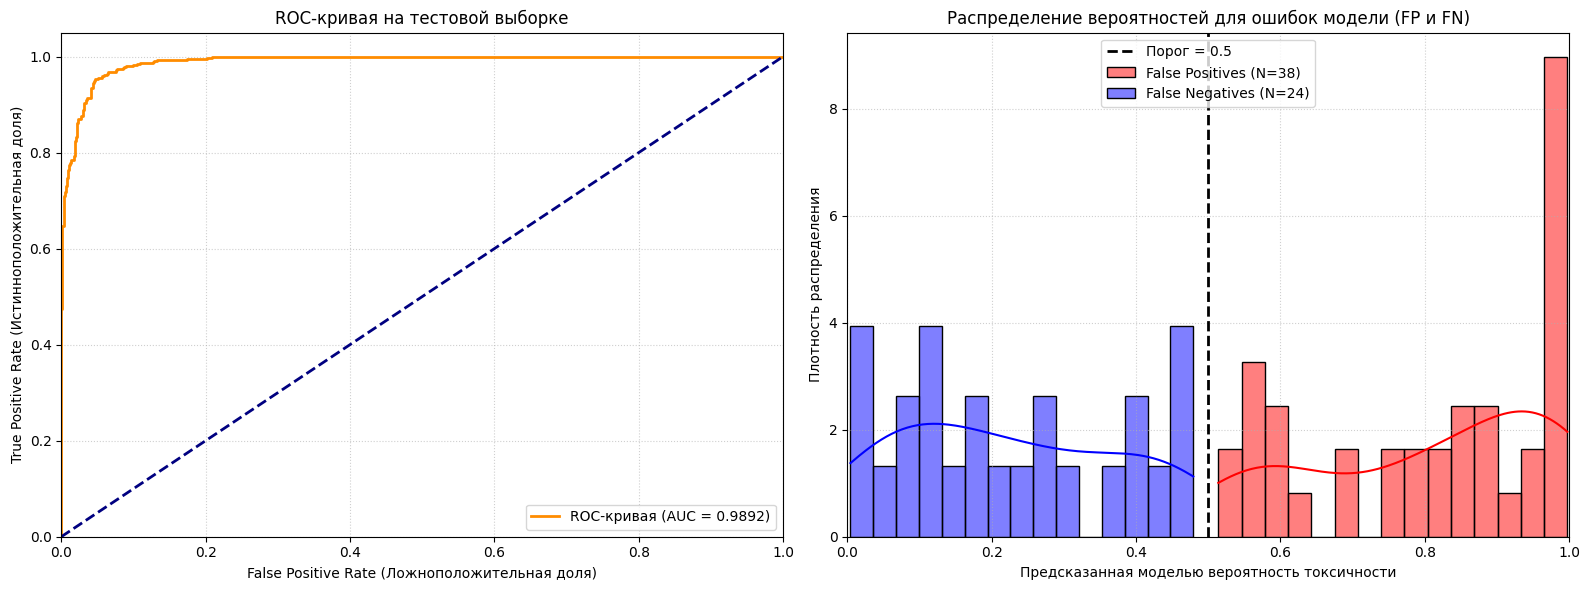


--- АНАЛИЗ ОШИБОК ---
Всего ошибок False Positives (модель ошиблась в нейтральном тексте): 38
Всего ошибок False Negatives (модель пропустила токсичный текст): 24


In [27]:
# === ВАШ КОД ЗДЕСЬ ===

# Опеределяем устройство, если оно не было задано ранее
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Вызовите evaluate_model и выведите метрики
results, all_preds, all_labels, all_probs = evaluate_model(model, test_loader, device=DEVICE)

print("\n--- МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ ---")
print(f"Accuracy:  {results['accuracy']:.4f}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall:    {results['recall']:.4f}")
print(f"F1-Score:  {results['f1']:.4f}")
print(f"MCC:       {results['mcc']:.4f}")
print(f"ROC AUC:   {results['roc_auc']:.4f}")

# 2. Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (Ложноположительная доля)')
axes[0].set_ylabel('True Positive Rate (Истинноположительная доля)')
axes[0].set_title('ROC-кривая на тестовой выборке')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=':', alpha=0.6)

# 3. Визуализация распределения вероятностей для ошибок (FP и FN)
threshold = 0.5

# Находим индексы ложноположительных и ложноотрицательных предсказаний
fp_mask = (all_preds == 1) & (all_labels == 0)
fn_mask = (all_preds == 0) & (all_labels == 1)

fp_probs = all_probs[fp_mask]
fn_probs = all_probs[fn_mask]

# Строим гистограммы распределения плотности вероятностей ошибок
if len(fp_probs) > 0:
    sns.histplot(fp_probs, kde=True, color='red', alpha=0.5, label=f'False Positives (N={len(fp_probs)})', ax=axes[1], bins=15, stat='density', common_norm=False)
if len(fn_probs) > 0:
    sns.histplot(fn_probs, kde=True, color='blue', alpha=0.5, label=f'False Negatives (N={len(fn_probs)})', ax=axes[1], bins=15, stat='density', common_norm=False)

axes[1].axvline(x=threshold, color='black', linestyle='--', lw=2, label=f'Порог = {threshold}')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_xlabel('Предсказанная моделью вероятность токсичности')
axes[1].set_ylabel('Плотность распределения')
axes[1].set_title('Распределение вероятностей для ошибок модели (FP и FN)')
axes[1].legend(loc="upper center")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Печатаем краткую сводку по ошибкам для наглядности
print("\n--- АНАЛИЗ ОШИБОК ---")
print(f"Всего ошибок False Positives (модель ошиблась в нейтральном тексте): {len(fp_probs)}")
print(f"Всего ошибок False Negatives (модель пропустила токсичный текст): {len(fn_probs)}")

# === КОНЕЦ ВАШЕГО КОДА ===

---

## Блок 8. Ручной инференс и замер времени GPU vs CPU (5 баллов)

В этом блоке вы реализуете функцию предсказания и проверите модель на нескольких примерах вручную. Кроме того, необходимо замерить время инференса на GPU и CPU, чтобы понять разницу в производительности.

**Что нужно сделать:**

1. Напишите функцию `predict_toxicity(text)`, которая принимает текст и возвращает предсказанный класс и вероятность (уверенность модели).
2. Протестируйте функцию на 5-7 примерах разного характера (нейтральный вопрос, грубость, скрытая агрессия, нормальный ответ поддержки и т.д.).
3. Замерьте время классификации одного и того же текста на GPU и на CPU. Используйте `time.time()` или `torch.cuda.Event` для точного замера.


In [28]:
import time
import torch
import torch.nn.functional as F

print("torch.cuda.is_available():", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if 'model' in locals() or 'model' in globals():
    live_model = model.model if hasattr(model, 'model') else model
    print("Используем обученную модель из оперативной памяти.")
else:
    print("⚠️ Переменная model не найдена в памяти!")

live_model = live_model.to(DEVICE)
live_model.eval()

# 1. Функция предсказания по логитам
def predict_by_logits(text, eval_model, tokenizer, device):
    eval_model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    ).to(device)

    with torch.no_grad():
        outputs = eval_model(**inputs)
        logits = outputs.logits # Получаем сырые выходы модели до софтмакса

    # Переводим в numpy для вывода
    logits_np = logits.cpu().numpy()[0]

    # Итоговый класс — это просто индекс максимального логита (как в training_step!)
    pred_class = int(torch.argmax(logits, dim=-1).item())

    # Считаем софтмакс для очистки совести
    probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    prob_toxic = float(probs[1])

    return pred_class, prob_toxic, logits_np

# 2. Проверка примеров
test_texts = [
    "Здравствуйте, чем могу помочь?",
    "Вы что, совсем тупой? Я же уже объяснял!",
    "Пожалуйста, попробуйте перезагрузить устройство",
    "Да пошел ты, надоел уже со своими вопросами",
    "Ваш запрос принят, ожидайте ответа в течение 24 часов",
    "Ну конечно, ты как всегда всё сделал криво",
    "Спасибо за помощь, всё отлично!",
]

print("\n=== Тест сырых выходов модели ===")
for txt in test_texts:
    cls, prob, raw_logits = predict_by_logits(txt, live_model, tokenizer, device=DEVICE)
    label = "ТОКСИЧНО (1)" if cls == 1 else "нетоксично (0)"
    print(f"Текст: {txt}")
    print(f"  Логиты: [класс_0: {raw_logits[0]:.4f}, класс_1: {raw_logits[1]:.4f}]")
    print(f"  Вердикт (по argmax): {label} | Вероятность: {prob:.4f}")
    print()


    #Слишком плохой датасет, из за этого плохо определил

torch.cuda.is_available(): True
Используем обученную модель из оперативной памяти.

=== Тест сырых выходов модели ===
Текст: Здравствуйте, чем могу помочь?
  Логиты: [класс_0: 6.1023, класс_1: -7.2060]
  Вердикт (по argmax): нетоксично (0) | Вероятность: 0.0000

Текст: Вы что, совсем тупой? Я же уже объяснял!
  Логиты: [класс_0: 5.1855, класс_1: -6.2589]
  Вердикт (по argmax): нетоксично (0) | Вероятность: 0.0000

Текст: Пожалуйста, попробуйте перезагрузить устройство
  Логиты: [класс_0: 3.1582, класс_1: -3.9456]
  Вердикт (по argmax): нетоксично (0) | Вероятность: 0.0008

Текст: Да пошел ты, надоел уже со своими вопросами
  Логиты: [класс_0: 2.4709, класс_1: -2.7836]
  Вердикт (по argmax): нетоксично (0) | Вероятность: 0.0052

Текст: Ваш запрос принят, ожидайте ответа в течение 24 часов
  Логиты: [класс_0: 3.0031, класс_1: -3.4806]
  Вердикт (по argmax): нетоксично (0) | Вероятность: 0.0015

Текст: Ну конечно, ты как всегда всё сделал криво
  Логиты: [класс_0: 4.6880, класс_1: -5.3614

---

## Блок 9. Публикация модели на Hugging Face (5 баллов)

Финальный шаг: публикация обученной модели на Hugging Face Hub. Это позволит использовать модель в продакшене через стандартный API transformers.

**Что нужно сделать:**

1. Загрузите сохраненные веса модели и токенизатор на Hugging Face Hub.
2. Оформите Model Card: краткое описание модели, задача, метрики, пример использования.


In [32]:
import os
from huggingface_hub import login, HfApi
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# === ВАШ КОД ЗАМЕНЕН НА ИСПРАВЛЕННЫЙ ===

HF_TOKEN = "token"
repo_id = "MisterWho31/russian-support-toxicity-classifier"

login(token=HF_TOKEN)

# Загрузка модели из памяти
model_to_upload = model.model if hasattr(model, 'model') else model
tokenizer_to_upload = tokenizer

# Публикация
print(f"Публикация в {repo_id}...")
model_to_upload.push_to_hub(repo_id)
tokenizer_to_upload.push_to_hub(repo_id)

# Создание README.md через конкатенацию строк (максимально надежно)
card_lines = [
    "---",
    "language: ru",
    "tags: [text-classification, toxicity]",
    "license: mit",
    "---",
    "",
    "# Russian Support Toxicity Classifier",
    "",
    "Модель для определения токсичности в текстах службы поддержки.",
    "Обучена на базе ai-forever/ru-en-RoSBERTa.",
    "",
    "## Пример использования",
    "```python",
    "from transformers import pipeline",
    "classifier = pipeline('text-classification', model='MisterWho31/russian-support-toxicity-classifier')",
    "print(classifier('Вы что, совсем тупой?'))",
    "```"
]
model_card = "\n".join(card_lines)

with open("README.md", "w", encoding="utf-8") as f:
    f.write(model_card)

api = HfApi()
api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=repo_id,
    repo_type="model",
    token=HF_TOKEN
)
print("Готово! Модель и описание на Hugging Face.")

Публикация в MisterWho31/russian-support-toxicity-classifier...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...6xkj8t_/model.safetensors:   1%|          | 15.5MB / 1.62GB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Готово! Модель и описание на Hugging Face.


---

## Критерии оценки

Для получения максимального балла за каждый блок убедитесь, что:

- Код работает без ошибок при последовательном запуске всех ячеек.
- Визуализации информативны и имеют подписи осей.
- Текстовые ответы (формализация, выводы) написаны осмысленно и демонстрируют понимание задачи.
- Датасет и модель на Hugging Face имеют оформленные карточки (Card).
- Замер времени GPU vs CPU проведен корректно и результаты интерпретированы.
